<a href="https://colab.research.google.com/github/ashleytrivino/arms_transfer_dsrp/blob/main/Ashley_Trivino_Arms_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [92]:
url ="https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Arms%20Transfers/arms_transfers_clean.csv"
df = pd.read_csv(url)
df.head()

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,United States,2015,55.0,M-1117 Guardian,armoured personnel carrier,55.0,2015,New,0.40,22.0,22.0
1,Afghanistan,United States,2004,188.0,M-113,armoured personnel carrier,188.0,2005,Second hand,0.10,18.8,18.8
2,Afghanistan,United States,2017,1673.0,HMMWV-UA,armoured personnel carrier,1673.0,2018; 2019; 2020; 2021,Second hand,0.05,87.0,87.0
3,Afghanistan,United States,2006,800.0,HMMWV-UA,armoured personnel carrier,800.0,2007; 2008,Second hand,0.05,41.6,41.6
4,Afghanistan,United States,2011,41.0,M-1117 Guardian,armoured personnel carrier,41.0,2011; 2012,New,0.40,16.4,16.4


In [93]:
df.info()
# number ordered, deliveries in the year range, year(s) of delivery have missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9756 entries, 0 to 9755
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       9756 non-null   object 
 1   Supplier                        9756 non-null   object 
 2   Year of order                   9756 non-null   int64  
 3   Number ordered                  9670 non-null   float64
 4   Weapon designation              9756 non-null   object 
 5   Weapon description              9756 non-null   object 
 6   Deliveries in the Year Range    9333 non-null   float64
 7   Year(s) of delivery             9333 non-null   object 
 8   status                          9756 non-null   object 
 9   SIPRI TIV per unit              9756 non-null   float64
 10  SIPRI TIV for total order       9756 non-null   float64
 11  SIPRI TIV of delivered weapons  9756 non-null   float64
dtypes: float64(5), int64(1), object(6)

In [94]:
df.describe()

,Year of order,Number ordered,Deliveries in the Year Range,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
count,9756.000000,9670.000000,9333.000000,9756.000000,9756.000000,9756.000000
mean,1987.274703,156.860703,154.585664,7.443830,94.357230,83.811894
std,22.060454,987.060460,997.650698,23.468209,337.544437,303.717951
min,1940.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1969.000000,3.000000,3.000000,0.240000,5.000000,4.200000
50%,1986.000000,12.000000,12.000000,1.000000,18.000000,16.000000
75%,2008.000000,60.000000,57.000000,5.000000,56.000000,52.575000
max,2025.000000,50000.000000,50000.000000,700.000000,10117.500000,10117.500000


In [95]:
df.columns

Index(['Recipient', 'Supplier', 'Year of order', 'Number ordered',
       'Weapon designation', 'Weapon description',
       'Deliveries in the Year Range', 'Year(s) of delivery', 'status',
       'SIPRI TIV per unit', 'SIPRI TIV for total order',
       'SIPRI TIV of delivered weapons'],
      dtype='object')

In [96]:
df = df.rename(columns={"Weapon description":"weapon_description", "Year of order":"year_of_order",
                        "Weapon designation":"weapon_designation", "Year(s) of delivery":"year(s)_of_delivery",
                        "SIPRI TIV per unit":"sipri_tiv_per_unit", "SIPRI TIV for total order":"sipri_tiv_for_total_order",
                        "SIPRI TIV of delivered weapons":"sipri_tiv_of_delivered_weapons",
                        "Number ordered":"number_ordered", "Recipient":"recipient", "Supplier":"supplier",
                        "Deliveries in the Year Range":"deliveries_in_year_range"})

In [97]:
df.columns

Index(['recipient', 'supplier', 'year_of_order', 'number_ordered',
       'weapon_designation', 'weapon_description', 'deliveries_in_year_range',
       'year(s)_of_delivery', 'status', 'sipri_tiv_per_unit',
       'sipri_tiv_for_total_order', 'sipri_tiv_of_delivered_weapons'],
      dtype='object')

In [98]:
df = df.drop_duplicates()

In [99]:
df.info()
# number ordered, deliveries in the year range, year(s) of delivery have missing values
# number ordered and deliveries in the year range are floats
# year(s) of delivery is an object since there are multiple numbers

<class 'pandas.core.frame.DataFrame'>
Index: 9741 entries, 0 to 9755
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   recipient                       9741 non-null   object 
 1   supplier                        9741 non-null   object 
 2   year_of_order                   9741 non-null   int64  
 3   number_ordered                  9656 non-null   float64
 4   weapon_designation              9741 non-null   object 
 5   weapon_description              9741 non-null   object 
 6   deliveries_in_year_range        9319 non-null   float64
 7   year(s)_of_delivery             9319 non-null   object 
 8   status                          9741 non-null   object 
 9   sipri_tiv_per_unit              9741 non-null   float64
 10  sipri_tiv_for_total_order       9741 non-null   float64
 11  sipri_tiv_of_delivered_weapons  9741 non-null   float64
dtypes: float64(5), int64(1), object(6)
memo

In [100]:
df = df.dropna(axis = 0, how = 'any', subset = ['number_ordered', 'deliveries_in_year_range'])

This dropped any rows with null values in either the 'Number Ordered' column or 'Deliveries in the Year Range' column

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9282 entries, 0 to 9755
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   recipient                       9282 non-null   object 
 1   supplier                        9282 non-null   object 
 2   year_of_order                   9282 non-null   int64  
 3   number_ordered                  9282 non-null   float64
 4   weapon_designation              9282 non-null   object 
 5   weapon_description              9282 non-null   object 
 6   deliveries_in_year_range        9282 non-null   float64
 7   year(s)_of_delivery             9282 non-null   object 
 8   status                          9282 non-null   object 
 9   sipri_tiv_per_unit              9282 non-null   float64
 10  sipri_tiv_for_total_order       9282 non-null   float64
 11  sipri_tiv_of_delivered_weapons  9282 non-null   float64
dtypes: float64(5), int64(1), object(6)
memo

In [102]:
df.describe()

,year_of_order,number_ordered,deliveries_in_year_range,sipri_tiv_per_unit,sipri_tiv_for_total_order,sipri_tiv_of_delivered_weapons
count,9282.000000,9282.000000,9282.000000,9282.000000,9282.000000,9282.000000
mean,1985.493967,155.064426,151.068197,7.370628,92.084891,87.841741
std,21.084221,995.695751,978.172262,23.537195,333.621893,310.788416
min,1940.000000,1.000000,1.000000,0.000000,0.040000,0.040000
25%,1968.000000,3.000000,3.000000,0.240000,5.170000,5.040000
50%,1984.000000,12.000000,12.000000,1.000000,18.000000,18.000000
75%,2004.000000,59.000000,56.000000,5.000000,56.000000,55.000000
max,2025.000000,50000.000000,50000.000000,700.000000,10117.500000,10117.500000


In [103]:
df.head()

,recipient,supplier,year_of_order,number_ordered,weapon_designation,weapon_description,deliveries_in_year_range,year(s)_of_delivery,status,sipri_tiv_per_unit,sipri_tiv_for_total_order,sipri_tiv_of_delivered_weapons
0,Afghanistan,United States,2015,55.0,M-1117 Guardian,armoured personnel carrier,55.0,2015,New,0.40,22.0,22.0
1,Afghanistan,United States,2004,188.0,M-113,armoured personnel carrier,188.0,2005,Second hand,0.10,18.8,18.8
2,Afghanistan,United States,2017,1673.0,HMMWV-UA,armoured personnel carrier,1673.0,2018; 2019; 2020; 2021,Second hand,0.05,87.0,87.0
3,Afghanistan,United States,2006,800.0,HMMWV-UA,armoured personnel carrier,800.0,2007; 2008,Second hand,0.05,41.6,41.6
4,Afghanistan,United States,2011,41.0,M-1117 Guardian,armoured personnel carrier,41.0,2011; 2012,New,0.40,16.4,16.4


In [104]:
df['supplier'].unique()

array(['United States', 'Germany', 'Israel', 'Spain', 'Norway', 'France',
       'South Vietnam', 'Canada', 'Italy', 'Singapore', 'Australia',
       'United Kingdom', 'Sweden', 'South Africa', 'Brazil',
       'Netherlands', 'Switzerland', 'Chad', 'Japan', 'Austria', 'Russia',
       'Saudi Arabia', 'New Zealand', 'Poland', 'unknown supplier(s)',
       'Egypt', 'Moldova', 'Jordan', 'South Korea', 'Peru', 'Bulgaria',
       'Ukraine', 'Denmark', 'Mujahedin (Afghanistan)*', 'Taiwan',
       'Czechia'], dtype=object)

In [105]:
df['recipient'].unique()

array(['Afghanistan', 'African Union**', 'Albania', 'Algeria', 'Angola',
       'Anti-Castro rebels (Cuba)*', 'Argentina', 'Armas (Guatemala)*',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belgium', 'Belize', 'Benin', 'Biafra',
       'Bolivia', 'Bosnia-Herzegovina', 'Botswana', 'Brazil', 'Brunei',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Contras (Nicaragua)*', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark', 'Djibouti',
       'Dominican Republic', 'DR Congo', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Estonia', 'Ethiopia', 'Fiji',
       'Finland', 'France', 'Gabon', 'Georgia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guyana', 'Haiti',
       'Haiti rebels*', 'Honduras', 'Hungary', 'India', 'Indonesia',
       'Indonesia rebels*',

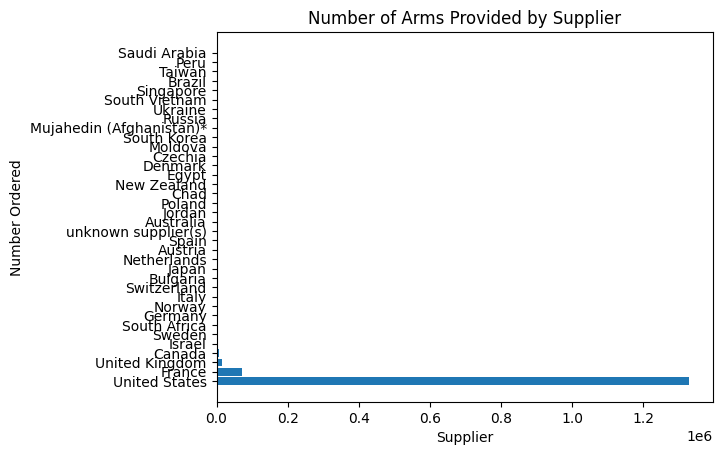

In [119]:
supplier_total_arms = df.groupby('supplier')['number_ordered'].sum().sort_values(ascending = False)

plt.barh(supplier_total_arms.index, supplier_total_arms.values)
plt.xlabel('Supplier')
plt.ylabel('Number Ordered')
plt.title('Number of Arms Provided by Supplier')
plt.show()

In [120]:
supplier_total_arms.head(10)

,number_ordered
supplier,
United States,1328024.0
France,71013.0
United Kingdom,16095.0
Canada,7770.0
Israel,4393.0
Sweden,3233.0
South Africa,2382.0
Germany,1587.0
Norway,1479.0


The US supplied the most arms involved in arms transfers globally

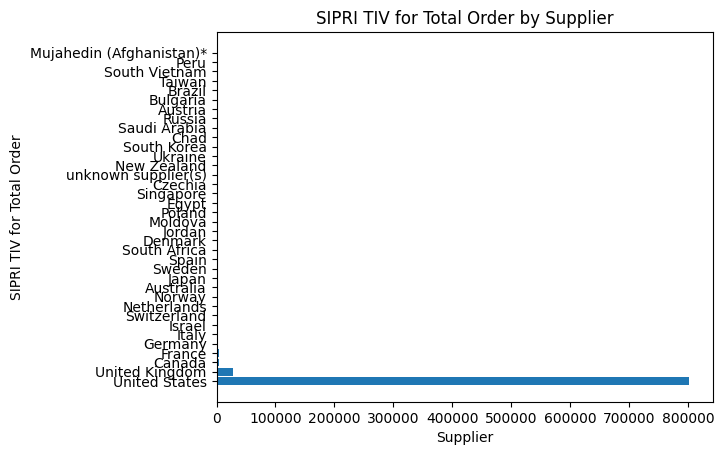

In [117]:
supplier_total_tiv = df.groupby('supplier')['sipri_tiv_for_total_order'].sum().sort_values(ascending = False)

plt.barh(supplier_total_tiv.index, supplier_total_tiv.values)
plt.xlabel('Supplier')
plt.ylabel('SIPRI TIV for Total Order')
plt.title('SIPRI TIV for Total Order by Supplier')
plt.show()

In [118]:
supplier_total_tiv.head(10)

,sipri_tiv_for_total_order
supplier,
United States,801701.78
United Kingdom,27834.68
Canada,4087.82
France,3521.90
Germany,2949.85
Italy,2384.40
Israel,2087.89
Switzerland,1830.10
Netherlands,1829.00


The United States supplied the most valuable arms in total in the global arms transfer

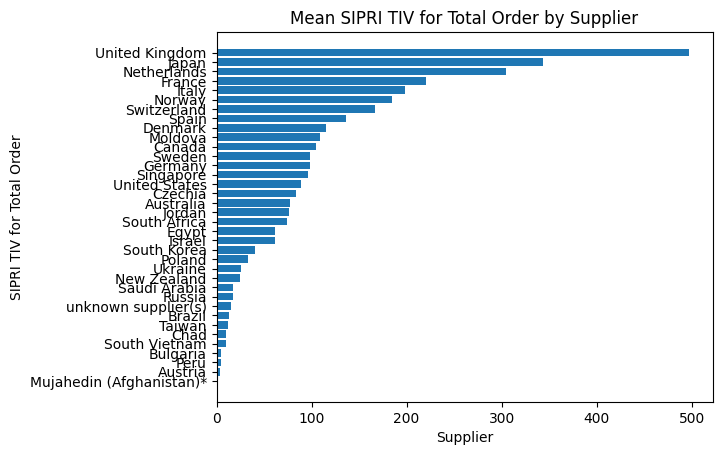

In [108]:
means = df.groupby('supplier')['sipri_tiv_for_total_order'].mean().sort_values(ascending = True)
plt.barh(means.index, means.values)
plt.xlabel('Supplier')
plt.ylabel('SIPRI TIV for Total Order')
plt.title('Mean SIPRI TIV for Total Order by Supplier')
plt.show()

The UK has the most mean sipri tiv for total order so that means within each order, they are sending the most valuable arms

In [109]:
recipient_orders = df.groupby('recipient')['number_ordered'].sum().sort_values(ascending=False)
display(recipient_orders.head(15))

,number_ordered
recipient,
Saudi Arabia,122867.0
United States,111284.0
Israel,97281.0
Ukraine,80861.0
United Kingdom,75959.0
Germany,74410.0
United Arab Emirates,51243.0
Turkiye,50833.0
Italy,50669.0


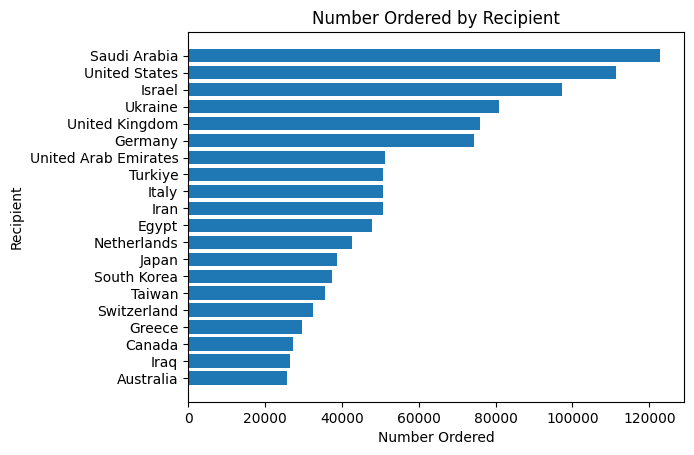

In [140]:
recipient_orders_a = recipient_orders.head(20).sort_values(ascending=True)

plt.barh(recipient_orders_a.index, recipient_orders_a.values)
plt.xlabel('Number Ordered')
plt.ylabel('Recipient')
plt.title('Number Ordered by Recipient')
plt.show()

Saudi Arabia, the US, and Israel ordered the most weapons by a large amount. Why?

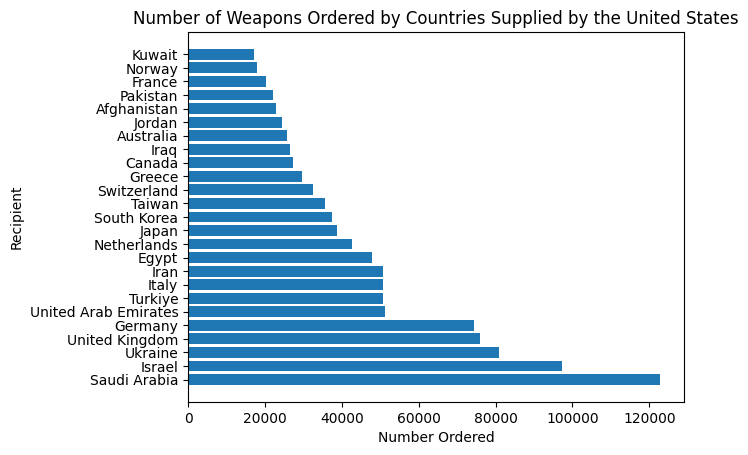

In [115]:
us_supplied_orders = df[df['supplier'] == 'United States'].groupby('recipient')['number_ordered'].sum().sort_values(ascending=False).head(25)

plt.barh(us_supplied_orders.index, us_supplied_orders.values)
plt.xlabel('Number Ordered')
plt.ylabel('Recipient')
plt.title('Number of Weapons Ordered by Countries Supplied by the United States')
plt.show()

The other top 2 countries that ordered the most weapons besides the US are  supplied by the US

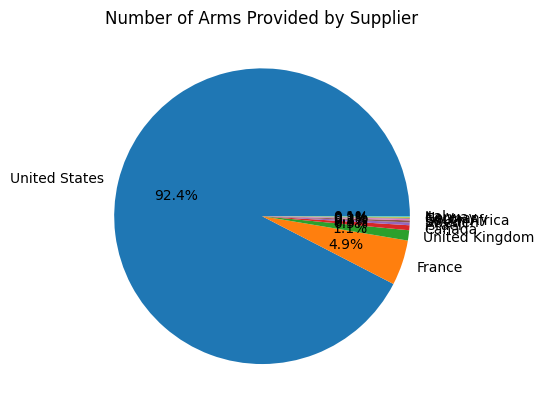

In [126]:
fig, ax = plt.subplots()
ax.pie(supplier_total_arms.head(10), labels=supplier_total_arms.head(10).index, autopct='%1.1f%%')
ax.set_title('Number of Arms Provided by Supplier')
plt.show()

The US dominates the market

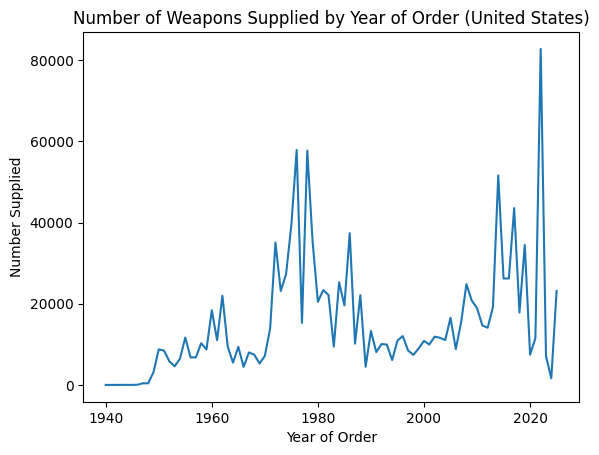

In [139]:
us_supplied_years = df[df['supplier'] == 'United States'].groupby('year_of_order')['number_ordered'].sum()
us_recipient_years = df[df['supplier'] == 'United States'].groupby('year_of_order')['recipient'].count()

plt.plot(us_supplied_years.index, us_supplied_years.values)
plt.xlabel('Year of Order')
plt.ylabel('Number Supplied')
plt.title('Number of Weapons Supplied by Year of Order (United States)')
plt.show()

peaked during the cold war and the start for russian ukraine war

In [ ]:
# to do - find out the years that israel and saudi arabia order.  after find year, find delivery in year range